# Occlusion Generation Demo

This notebook demonstrates how to use the `oasic` package to create synthetic occlusions on images. This is useful for:
- Data augmentation during training
- Testing model robustness to occlusions
- Generating evaluation datasets

In [ ]:
import torch
import matplotlib.pyplot as plt
from torchvision.io import decode_image, read_image, ImageReadMode
from torchvision.transforms import v2
from glob import glob

from occlusion_generation import (
    # Transforms
    ApplyGrayOcclusion,
    ApplyOverlayOcclusion,
    ApplyFromToGrayOcclusion,
    # Low-level mask functions
    slide_blackout_mask,
    bars_blackout_mask,
    grid_dropout_mask,
    perlin_mask,
)

## 0. Specify A Source Image

First, we need to specify a source image that we want to apply occlusions to. 

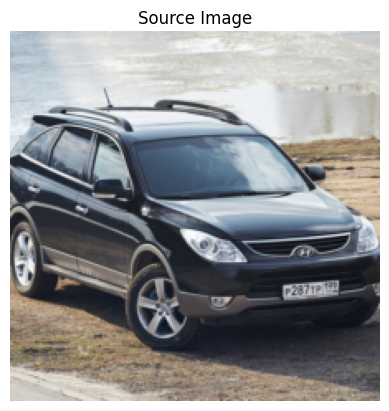

In [2]:
source_image_path = "examples/data/samples/010972.jpg"

source_tensor = read_image(source_image_path, mode=ImageReadMode.RGB)

transform = v2.Compose([
    v2.Resize(256, antialias=True),
    v2.CenterCrop(224),
])

source_tensor = transform(source_tensor) # Center crop to 224x224 for consistency with mask size

plt.imshow(source_tensor.permute(1, 2, 0))
plt.axis("off")
plt.title("Source Image")
plt.show()

## 1. Mask Generation Functions

The library provides four mask generation patterns:
- **Slide Blackout**: Occludes the left or right side of the image
- **Bars Blackout**: Creates vertical bars distributed across the image
- **Grid Dropout**: Randomly drops out grid cells
- **Perlin Noise**: Creates natural, blob-like occlusion regions

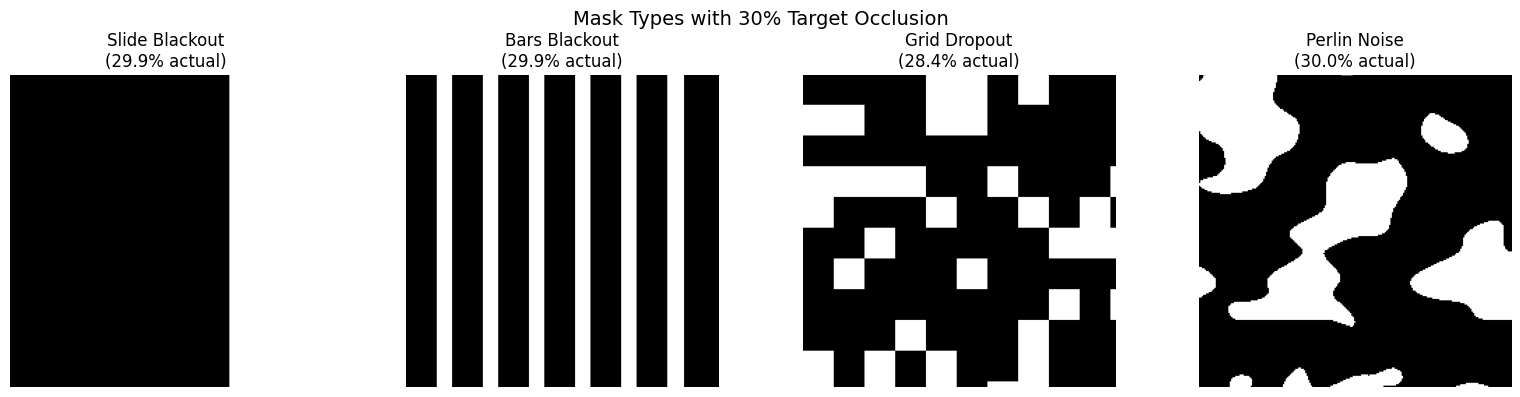

In [3]:
height, width = 224, 224
occlusion_percent = 30

# Generate all mask types
masks = [
    (slide_blackout_mask(height, width, occlusion_percent), "Slide Blackout"),
    (bars_blackout_mask(height, width, occlusion_percent), "Bars Blackout"),
    (grid_dropout_mask(height, width, occlusion_percent), "Grid Dropout"),
    (perlin_mask(height, width, occlusion_percent), "Perlin Noise"),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, (mask, name) in enumerate(masks):
    actual_pct = mask.sum() / mask.numel() * 100
    axes[idx].imshow(mask, cmap="gray")
    axes[idx].set_title(f"{name}\n({actual_pct:.1f}% actual)")
    axes[idx].axis("off")

plt.suptitle(f"Mask Types with {occlusion_percent}% Target Occlusion", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Gray Pattern Occlusion Transform

Use `ApplyGrayOcclusion` to apply geometric occlusion patterns with a solid color fill.

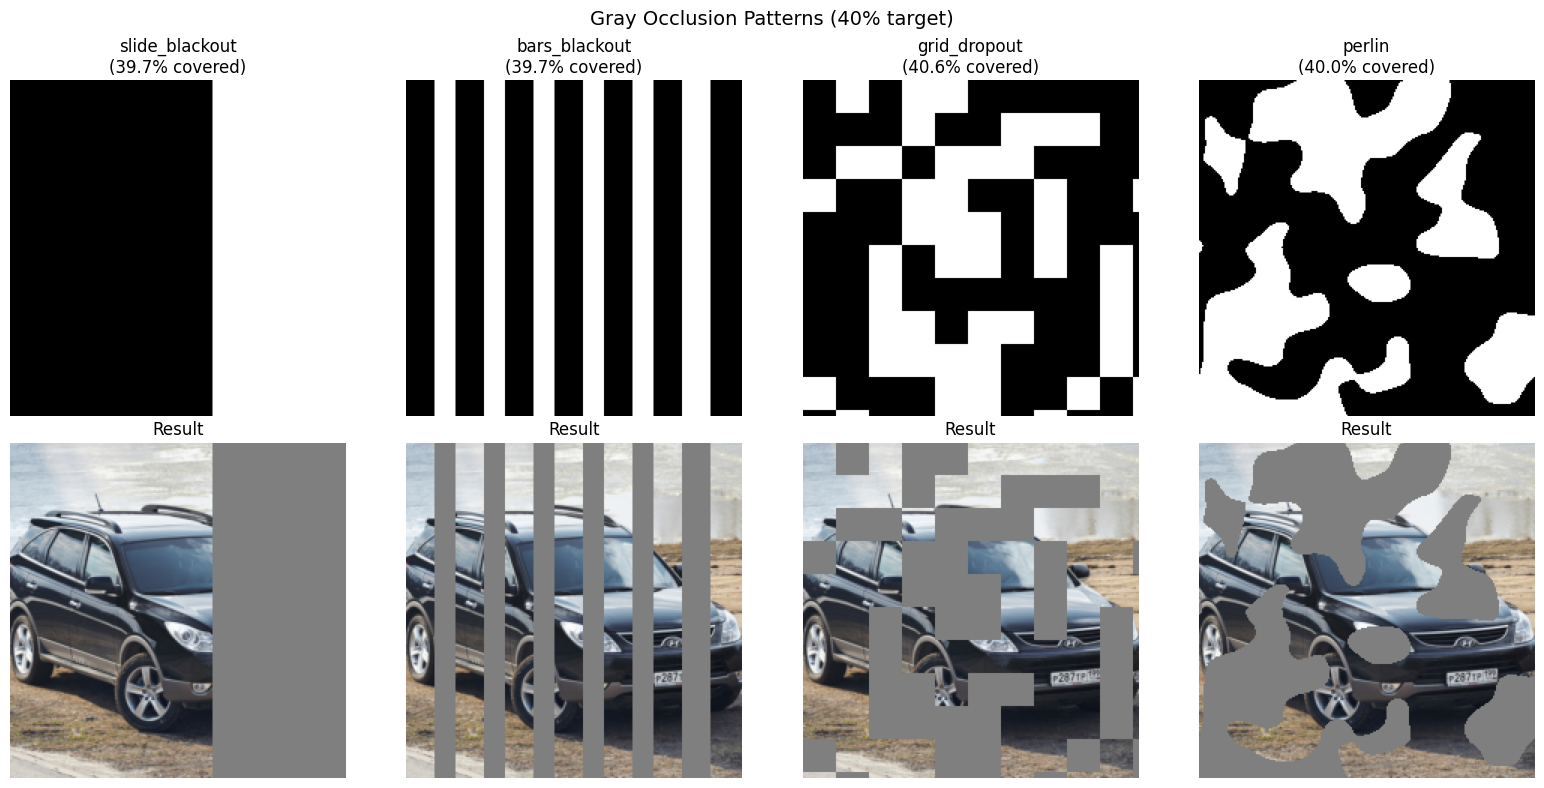

In [4]:
# Available occlusion types
occlusion_types = ["slide_blackout", "bars_blackout", "grid_dropout", "perlin"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, occ_type in enumerate(occlusion_types):
    transform = ApplyGrayOcclusion(
        occlusion_percent=40,
        occlusion_type=occ_type,
        occlusion_color=(127, 127, 127),
        return_mask=True
    )
    
    occluded, mask = transform(source_tensor)
    actual_pct = mask.sum() / mask.numel() * 100
    
    # Show mask
    axes[0, idx].imshow(mask, cmap="gray")
    axes[0, idx].set_title(f"{occ_type}\n({actual_pct:.1f}% covered)")
    axes[0, idx].axis("off")
    
    # Show occluded image
    axes[1, idx].imshow(occluded.permute(1, 2, 0))
    axes[1, idx].set_title("Result")
    axes[1, idx].axis("off")

plt.suptitle("Gray Occlusion Patterns (40% target)", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Vegetation Overlay Occlusion

Use `ApplyOverlayOcclusion` to apply realistic textured occlusions (e.g., vegetation, smoke) using RGBA overlay images.

In [ ]:
# Load the overlay png's
overlay_paths = glob("examples/data/overlays/*.png")
overlay_tensors = [decode_image(path, mode=ImageReadMode.RGB_ALPHA) for path in overlay_paths]

print(f"Created {len(overlay_tensors)} overlay cutouts")
print(f"Overlay shape (RGBA): {overlay_tensors[0].shape}") # 4 channels

['examples/data/overlays/mask_14.png', 'examples/data/overlays/mask_15.png', 'examples/data/overlays/mask_06.png', 'examples/data/overlays/mask_07.png', 'examples/data/overlays/mask_05.png', 'examples/data/overlays/mask_10.png', 'examples/data/overlays/mask_09.png', 'examples/data/overlays/mask_20.png', 'examples/data/overlays/mask_08.png', 'examples/data/overlays/mask_22.png', 'examples/data/overlays/mask_23.png']
Created 11 overlay cutouts
Overlay shape (RGBA): torch.Size([4, 103, 91])


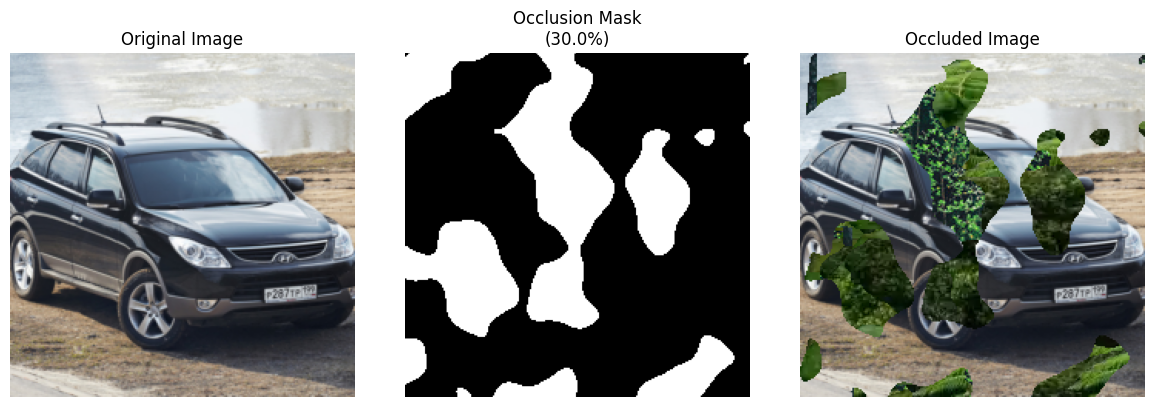

In [18]:
# Create the overlay occlusion transform
overlay_transform = ApplyOverlayOcclusion(
    overlays=overlay_tensors,
    occlusion_percent=30,
    occlusion_type="perlin",
    return_mask=True
)

# Apply the occlusion
occluded_image, occlusion_mask = overlay_transform(source_tensor)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(source_tensor.permute(1, 2, 0))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(occlusion_mask, cmap="gray")
axes[1].set_title(f"Occlusion Mask\n({occlusion_mask.sum() / occlusion_mask.numel() * 100:.1f}%)")
axes[1].axis("off")

axes[2].imshow(occluded_image.permute(1, 2, 0))
axes[2].set_title("Occluded Image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 4. Custom Occlusion Colors

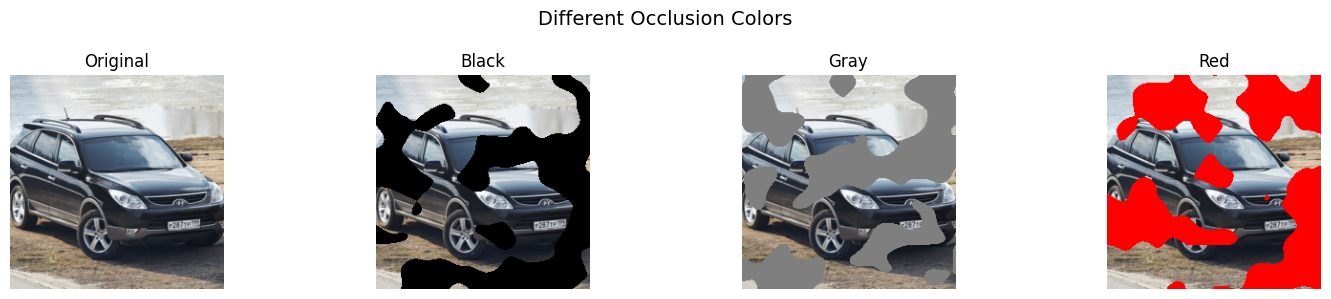

In [47]:
colors = [
    ((0, 0, 0), "Black"),
    ((127, 127, 127), "Gray"),
    ((255, 0, 0), "Red"),
]

fig, axes = plt.subplots(1, len(colors) + 1, figsize=(15, 3))

axes[0].imshow(source_tensor.permute(1, 2, 0))
axes[0].set_title("Original")
axes[0].axis("off")

for idx, (color, name) in enumerate(colors):
    transform = ApplyGrayOcclusion(
        occlusion_percent=40,
        occlusion_type="perlin",
        occlusion_color=color,
        return_mask=False
    )
    occluded = transform(source_tensor)
    
    axes[idx + 1].imshow(occluded.permute(1, 2, 0))
    axes[idx + 1].set_title(name)
    axes[idx + 1].axis("off")

plt.suptitle("Different Occlusion Colors", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Perlin Noise Parameters

The Perlin noise mask can be customized with several parameters:
| Parameter | Default | Effect |
|---|---|---|
| `scale` | `60.0` | Size of the noise blobs. Larger values produce bigger, coarser regions. |
| `octaves` | `2` | Number of noise passes summed together. More octaves add finer detail, but with diminishing returns as persistence lowers their contribution. |
| `persistence` | `0.5` | How much each successive octave contributes. Values below 1.0 make later octaves progressively quieter, keeping the overall pattern smooth with subtle detail. |
| `lacunarity` | `2.0` | Frequency multiplier between octaves. Higher values create sharp, small features against a smooth background; lower values keep everything smooth. |

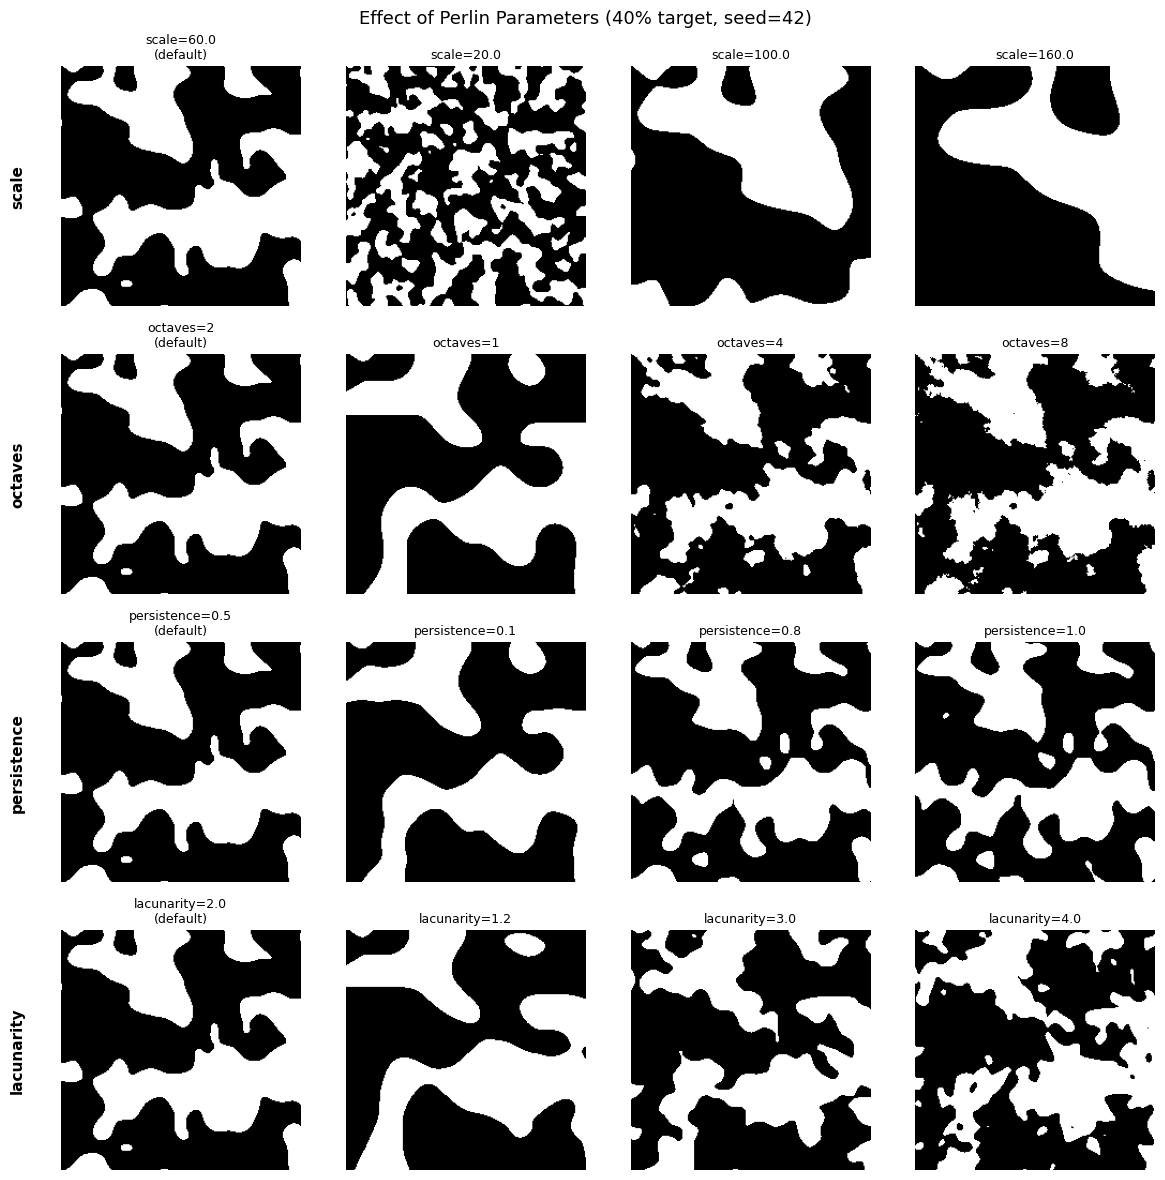

In [48]:
# Grid showing the effect of each Perlin parameter
# Row = parameter; Col 0 = default value, Cols 1-3 = other values of that parameter

defaults = dict(scale=60.0, octaves=2, persistence=0.5, lacunarity=2.0)

# (param_name, [default, val1, val2, val3])
param_variants = [
    ("scale",       [60.0,  20.0,  100.0, 160.0]),
    ("octaves",     [2,     1,     4,     8    ]),
    ("persistence", [0.5,   0.1,   0.8,   1.0  ]),
    ("lacunarity",  [2.0,   1.2,   3.0,   4.0  ]),
]

n_rows = len(param_variants)
n_cols = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))

for row, (param, values) in enumerate(param_variants):
    for col, val in enumerate(values):
        kwargs = {**defaults, param: val}
        mask = perlin_mask(224, 224, 40, seed=42, **kwargs)
        ax = axes[row, col]
        ax.imshow(mask, cmap="gray")
        ax.axis("off")
        title = f"{param}={val}" + ("\n(default)" if col == 0 else "")
        ax.set_title(title, fontsize=9)

    axes[row, 0].text(-0.15, 0.5, param, transform=axes[row, 0].transAxes,
                      fontsize=11, fontweight="bold", va="center", ha="right", rotation=90)

plt.suptitle("Effect of Perlin Parameters (40% target, seed=42)", fontsize=13)
plt.tight_layout()
plt.show()

### Reproducability with seeds

A random seed can be set for reproducible occlusion patterns, which is especially useful for consistent training data augmentation or evaluation datasets.

mask1 == mask2: True
mask1 == mask3: False


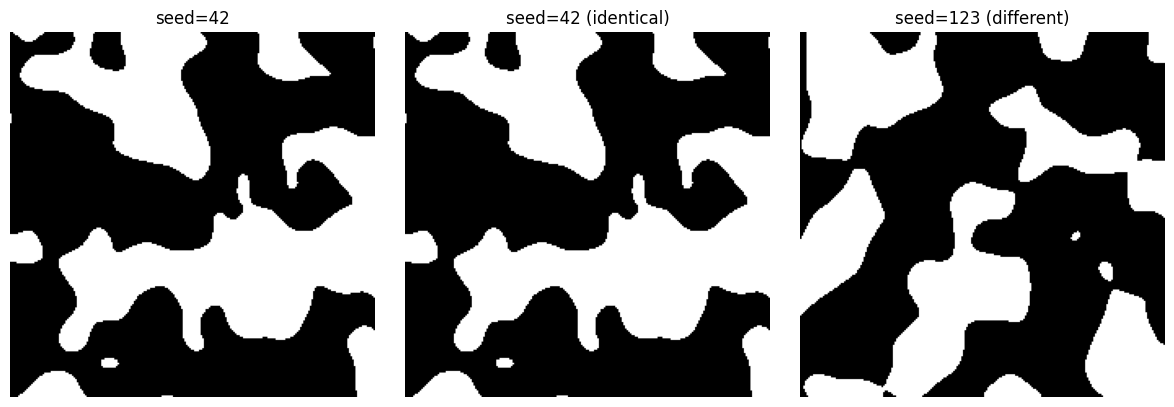

In [49]:
h, w, occlusion_percent = 224, 224, 40

mask1 = perlin_mask(h, w, occlusion_percent, seed=42)
mask2 = perlin_mask(h, w, occlusion_percent, seed=42)
mask3 = perlin_mask(h, w, occlusion_percent, seed=123)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(mask1, cmap="gray")
axes[0].set_title("seed=42")
axes[0].axis("off")

axes[1].imshow(mask2, cmap="gray")
axes[1].set_title("seed=42 (identical)")
axes[1].axis("off")

axes[2].imshow(mask3, cmap="gray")
axes[2].set_title("seed=123 (different)")
axes[2].axis("off")

print(f"mask1 == mask2: {torch.equal(mask1, mask2)}")
print(f"mask1 == mask3: {torch.equal(mask1, mask3)}")

plt.tight_layout()
plt.show()